In [1]:
import numpy as np
import periapsis as p
from astropy.table import Table
import matplotlib.pyplot as plt

# Fit for oMEGACat BH2
> Data from Whitaker et al. (2026)

In [2]:
data_table = Table.read("data/oMEGACat_Data/apjlae7a5ct1_mrt.txt",
                format="ascii.mrt")

clean= ~(data_table['Flag'] > 0)

t = np.asarray(data_table['Year'])[clean]
x = np.asarray(data_table['DeltaRA'])[clean]
y = np.asarray(data_table['DeltaDec'])[clean]
x_err = np.asarray(data_table['e_DeltaRA'])[clean]
y_err = np.asarray(data_table['e_DeltaDec'])[clean]
ref_epoch = 2012
m_vis = 0.78 #solar masses
distance = 5494 #pc


In [3]:
units = {'x':'mas', 'y':'mas', 't':'yr', 'x_err':'mas', 'y_err':'mas', 'M1':'Msun', 'distance':'pc'}
data = p.AstrometryData(t,x,y,x_err,y_err,ref_epoch=ref_epoch,units=units,system='1')

In [4]:
priors = {
    'P':p.UniformPrior(1.2,200),
    'e': p.UniformPrior(0,0.95),
    't0': p.UniformPrior(-0.5,0.5),
    'M1': p.FixedPrior(m_vis),
    'distance': p.FixedPrior(distance)
}

In [5]:
fitter1 = p.UltranestLinearFitter(
    output_params = ['P','e','t0'],
    min_num_live_points = 1000,
    min_ess = 800,
    **priors

)
results1 = fitter1.fit(data)

[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-6e+02  .90 [-589.9855..-589.9854]*| it/evals=12600/37208 eff=34.7989% N=1000 
[ultranest] Likelihood function evaluations: 37253
[ultranest]   logZ = -598 +- 0.0689
[ultranest] Effective samples strategy satisfied (ESS = 4619.5, need >800)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.07, need <0.5)
[ultranest]   logZ error budget: single: 0.08 bs:0.07 tail:0.01 total:0.07 required:<0.50
[ultranest] done iterating.


In [6]:
stats, fit_results = p.all_stats(results1,data)

{
    "credible_intervals": {
        "A1": {
            "+1sigma": -0.16114924145071519,
            "+2sigma": 0.13940758325764466,
            "-1sigma": -0.9034512863928724,
            "-2sigma": -1.5511678254978924
        },
        "B1": {
            "+1sigma": -1.4217947199081347,
            "+2sigma": -1.0532415866607059,
            "-1sigma": -3.2360776504143884,
            "-2sigma": -3.908813825686556
        },
        "F1": {
            "+1sigma": 7.9966341544785955,
            "+2sigma": 9.989139264131055,
            "-1sigma": 3.0323994506305145,
            "-2sigma": 2.0765500739966902
        },
        "G1": {
            "+1sigma": -0.8912306082996009,
            "+2sigma": -0.6159493427853586,
            "-1sigma": -2.0608106357242297,
            "-2sigma": -2.761962610404263
        },
        "M2": {
            "+1sigma": 5.654724535369083,
            "+2sigma": 7.374743433357186,
            "-1sigma": 3.388565266969737,
            "-2sigma": 2.6

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


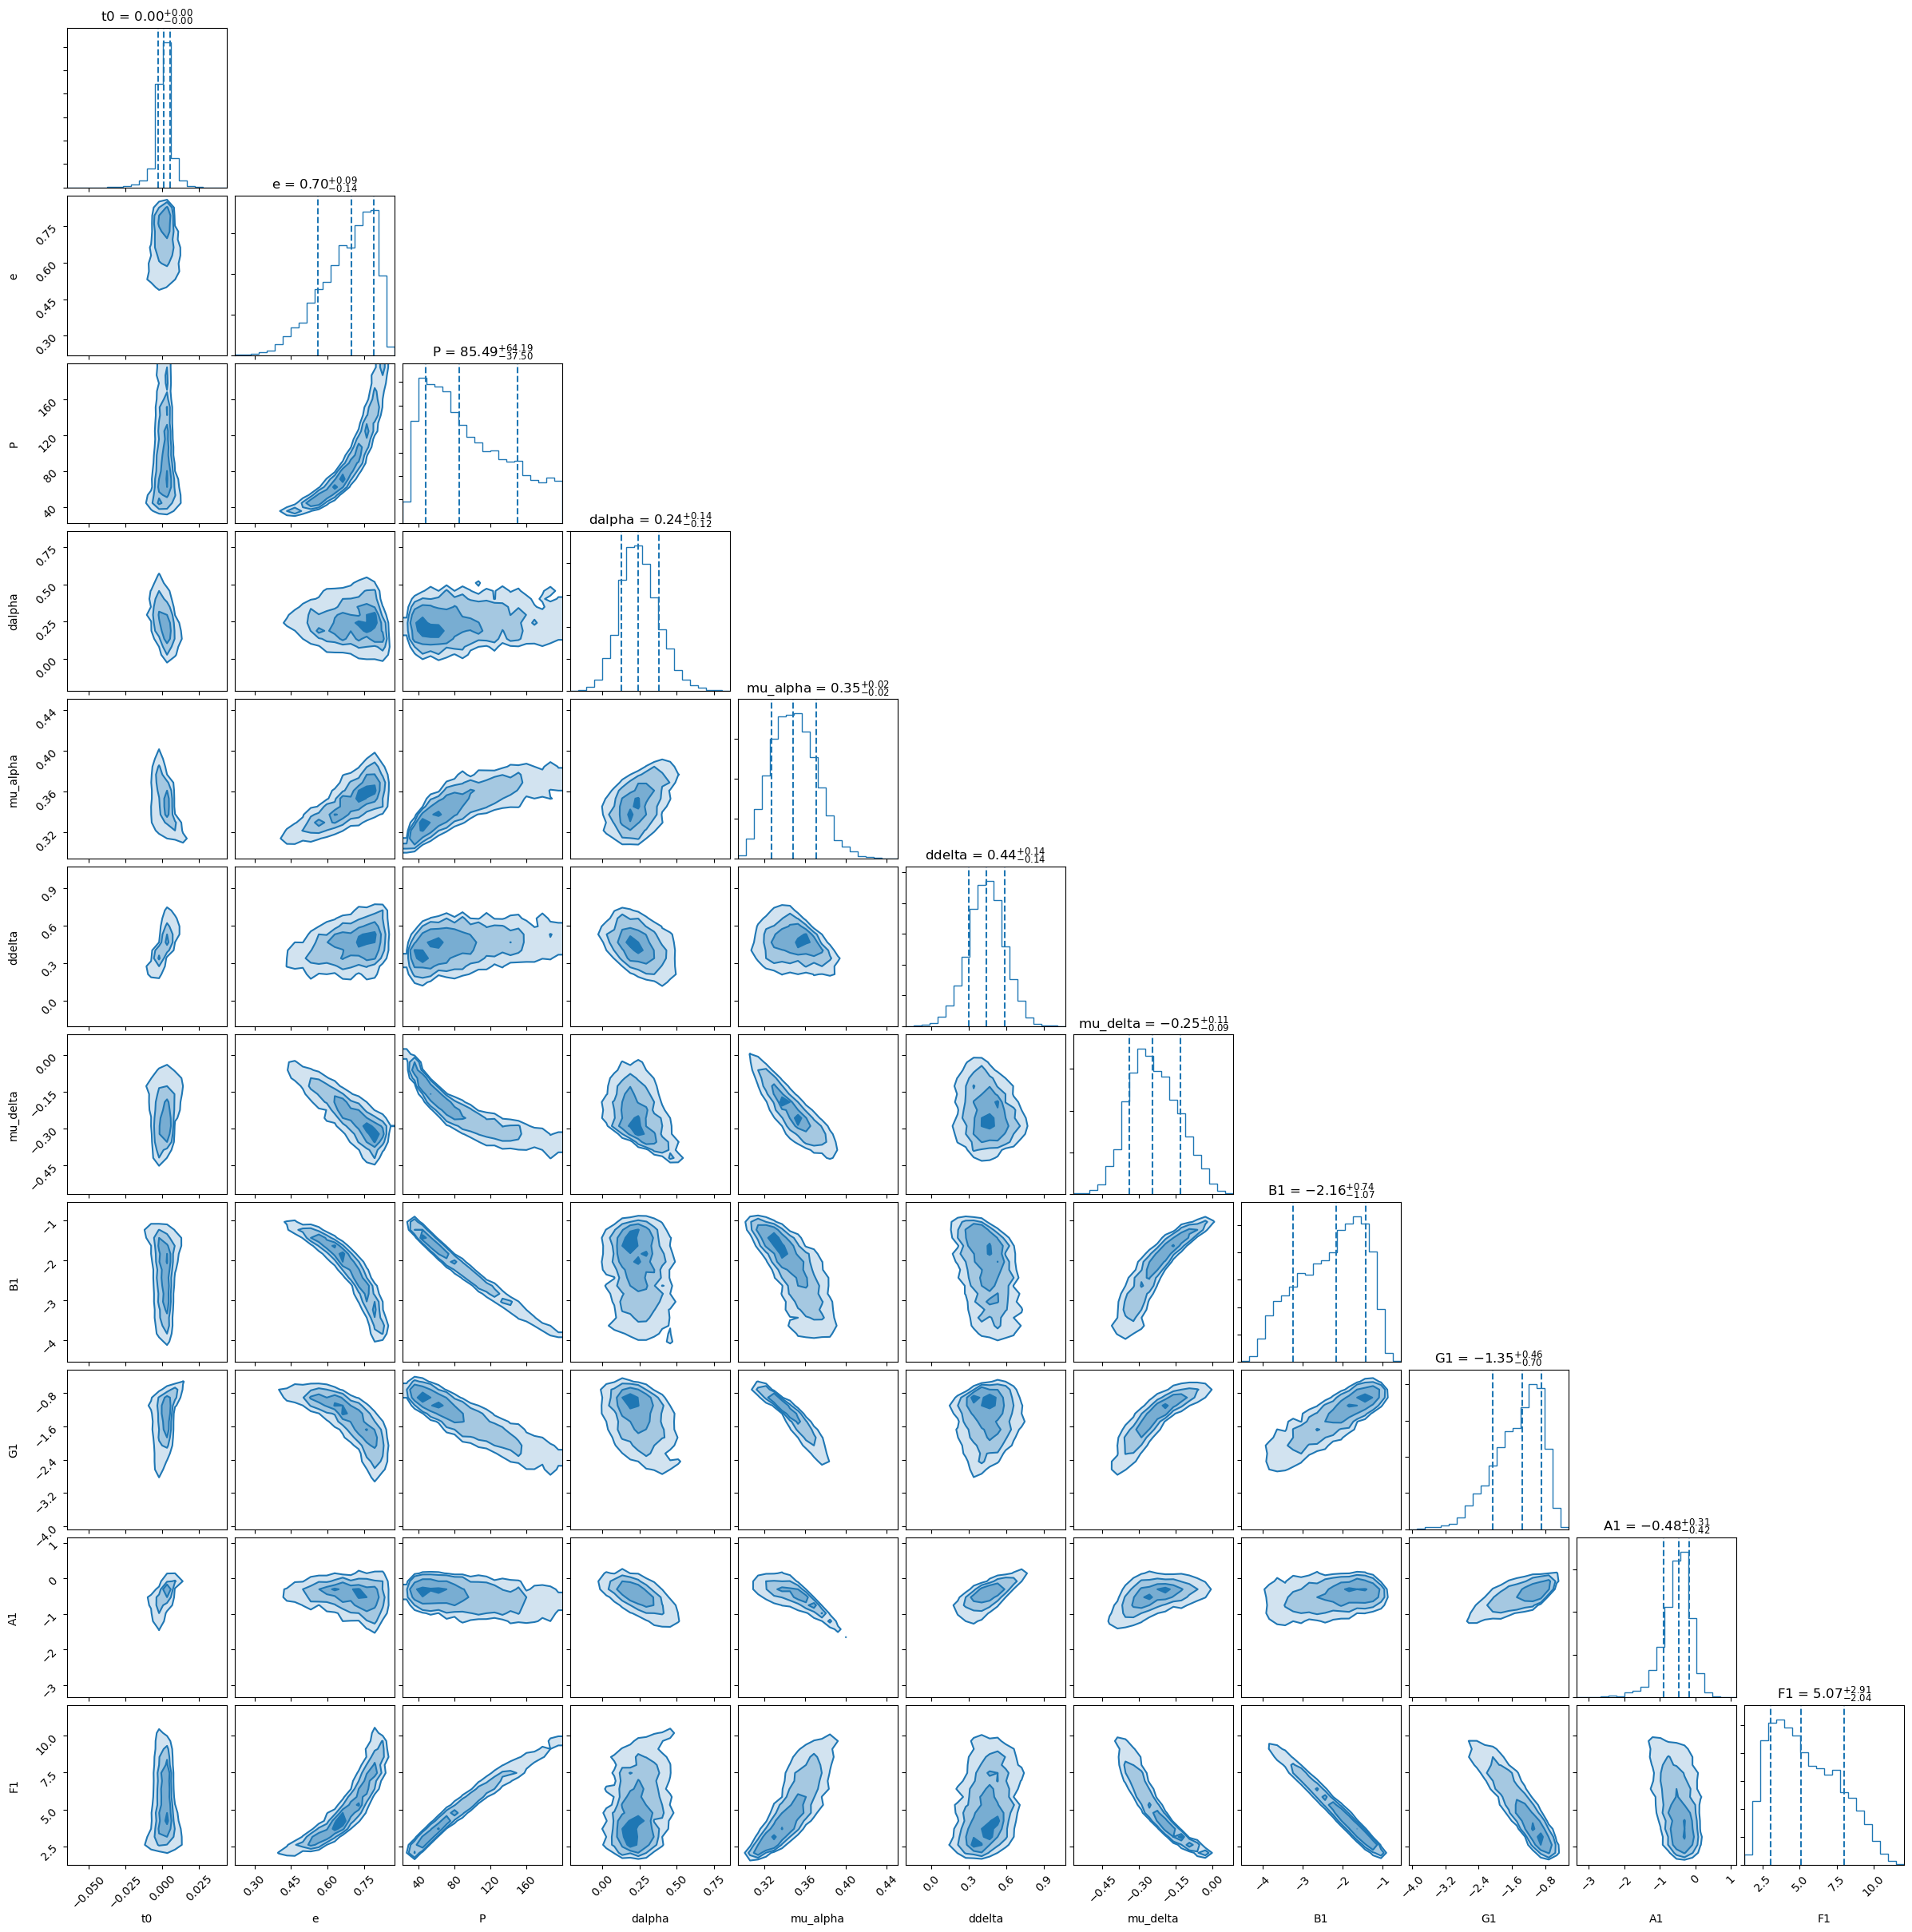

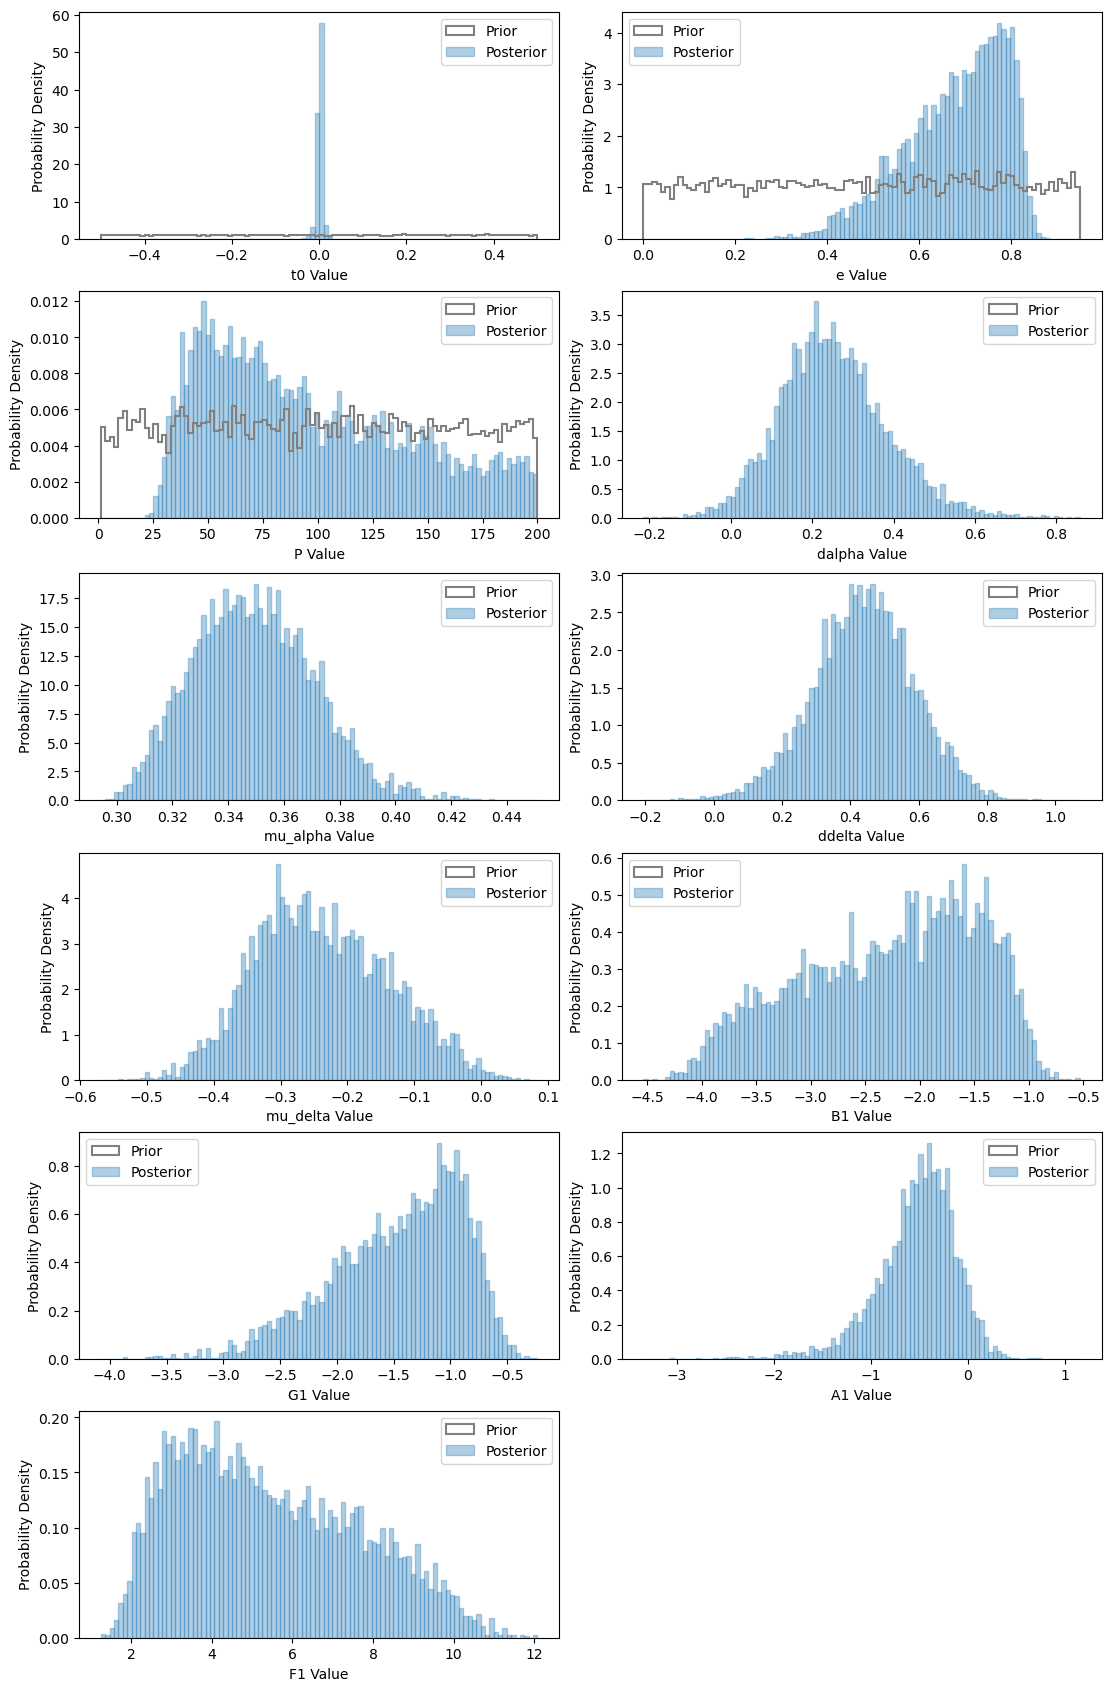

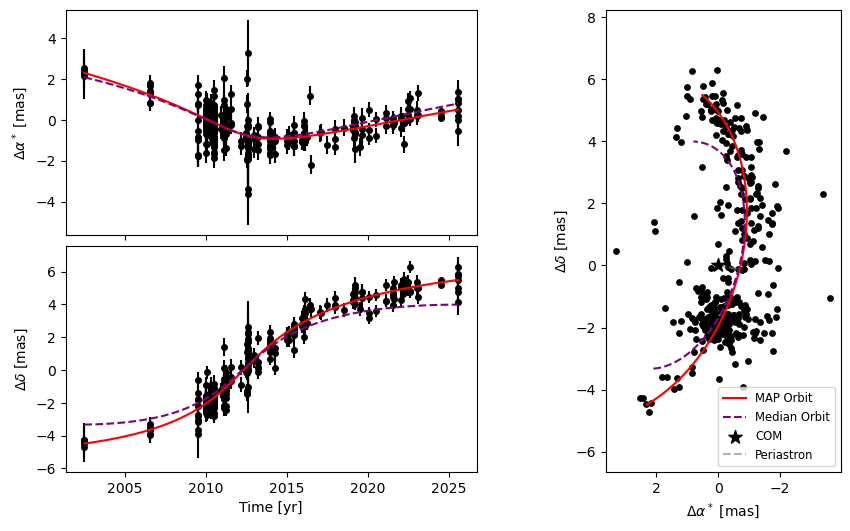

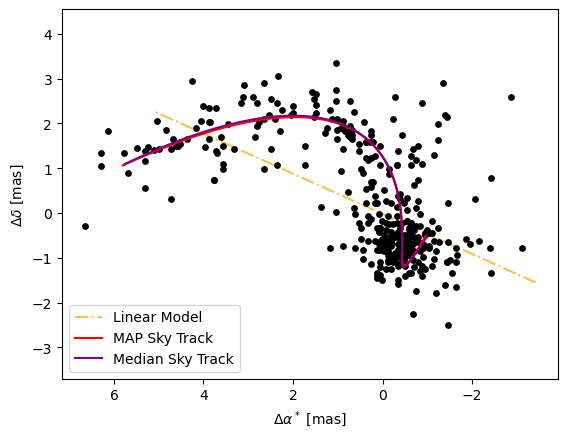

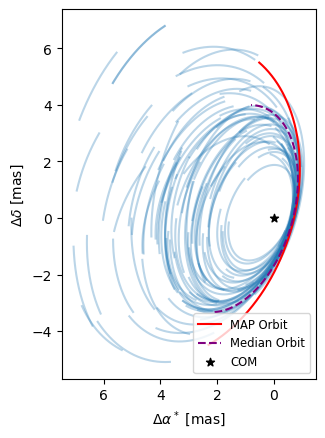

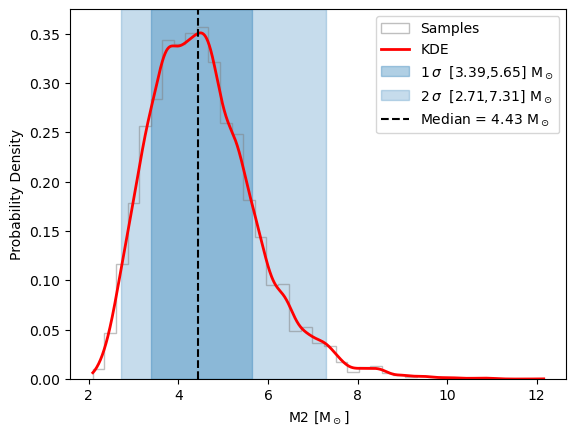

In [7]:
p.all_plots(results1,data)

In [8]:
priors_full = {
    'P':p.UniformPrior(1.2,200),
    'e': p.UniformPrior(0,0.95),
    't0': p.UniformPrior(-0.5,0.5),
    'a1': p.UniformPrior(0.1, 100),
    'cosi': p.UniformPrior(-1,1),
    'omega1': p.UniformPrior(0,2*np.pi),
    'Omega1': p.UniformPrior(0,2*np.pi),
    'M1': p.FixedPrior(m_vis),
    'distance': p.FixedPrior(distance),
    'dalpha': p.UniformPrior(-10,10),
    'ddelta': p.UniformPrior(-10,10),
    'mu_alpha': p.UniformPrior(-10,10),
    'mu_delta': p.UniformPrior(-10,10)
}

In [9]:
fitter2 = p.MCMCFitter(
    nwalkers = 100,
    niter = 50000,
    sample_params = ['P','e','t0','a1','cosi','omega1','Omega1','dalpha','ddelta','mu_alpha','mu_delta'],
    **priors_full
)
results2 = fitter2.fit(data,rng=np.random.default_rng(1234))

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
100%|██████████| 50000/50000 [19:50<00:00, 41.99it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1000;
tau: [3079.99369961 3373.70865084  914.98136351 3127.91182623 2410.96511176
  754.78700857 1344.39248191  655.5572814   840.1036275  1963.87291821
 3208.8130787 ]


In [10]:
stats2, fit_results2 = p.all_stats(results2,data)

{
    "Ess": [
        1623.3799441312706,
        1482.0485458228504,
        5464.592175780669,
        1598.5105328320637,
        2073.8582966637723,
        6624.385347422342,
        3719.1520090284275,
        7627.0985646604695,
        5951.646721141709,
        2545.9895870254063,
        1558.2085579233426
    ],
    "credible_intervals": {
        "M2": {
            "+1sigma": 5.8521535633197965,
            "+2sigma": 7.771545606605684,
            "-1sigma": 3.4358791184573825,
            "-2sigma": 2.681970613425264
        },
        "Omega1": {
            "+1sigma": 6.06083140293584,
            "+2sigma": 6.119619660688811,
            "-1sigma": 5.953153008191229,
            "-2sigma": 5.88834209497088
        },
        "P": {
            "+1sigma": 162.32307316066687,
            "+2sigma": 192.90097783663177,
            "-1sigma": 51.17657619239449,
            "-2sigma": 34.13668241677343
        },
        "a1": {
            "+1sigma": 8.780309501149347,
 

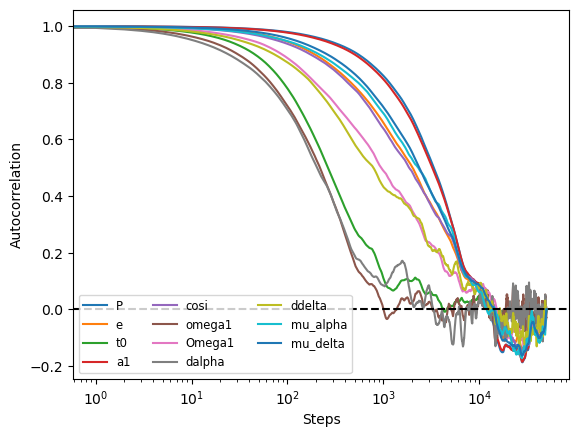

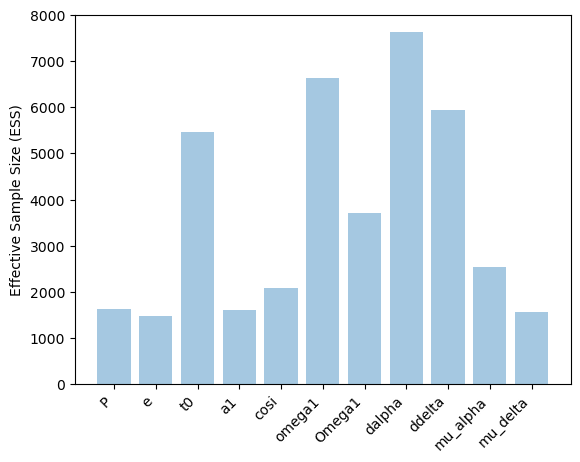

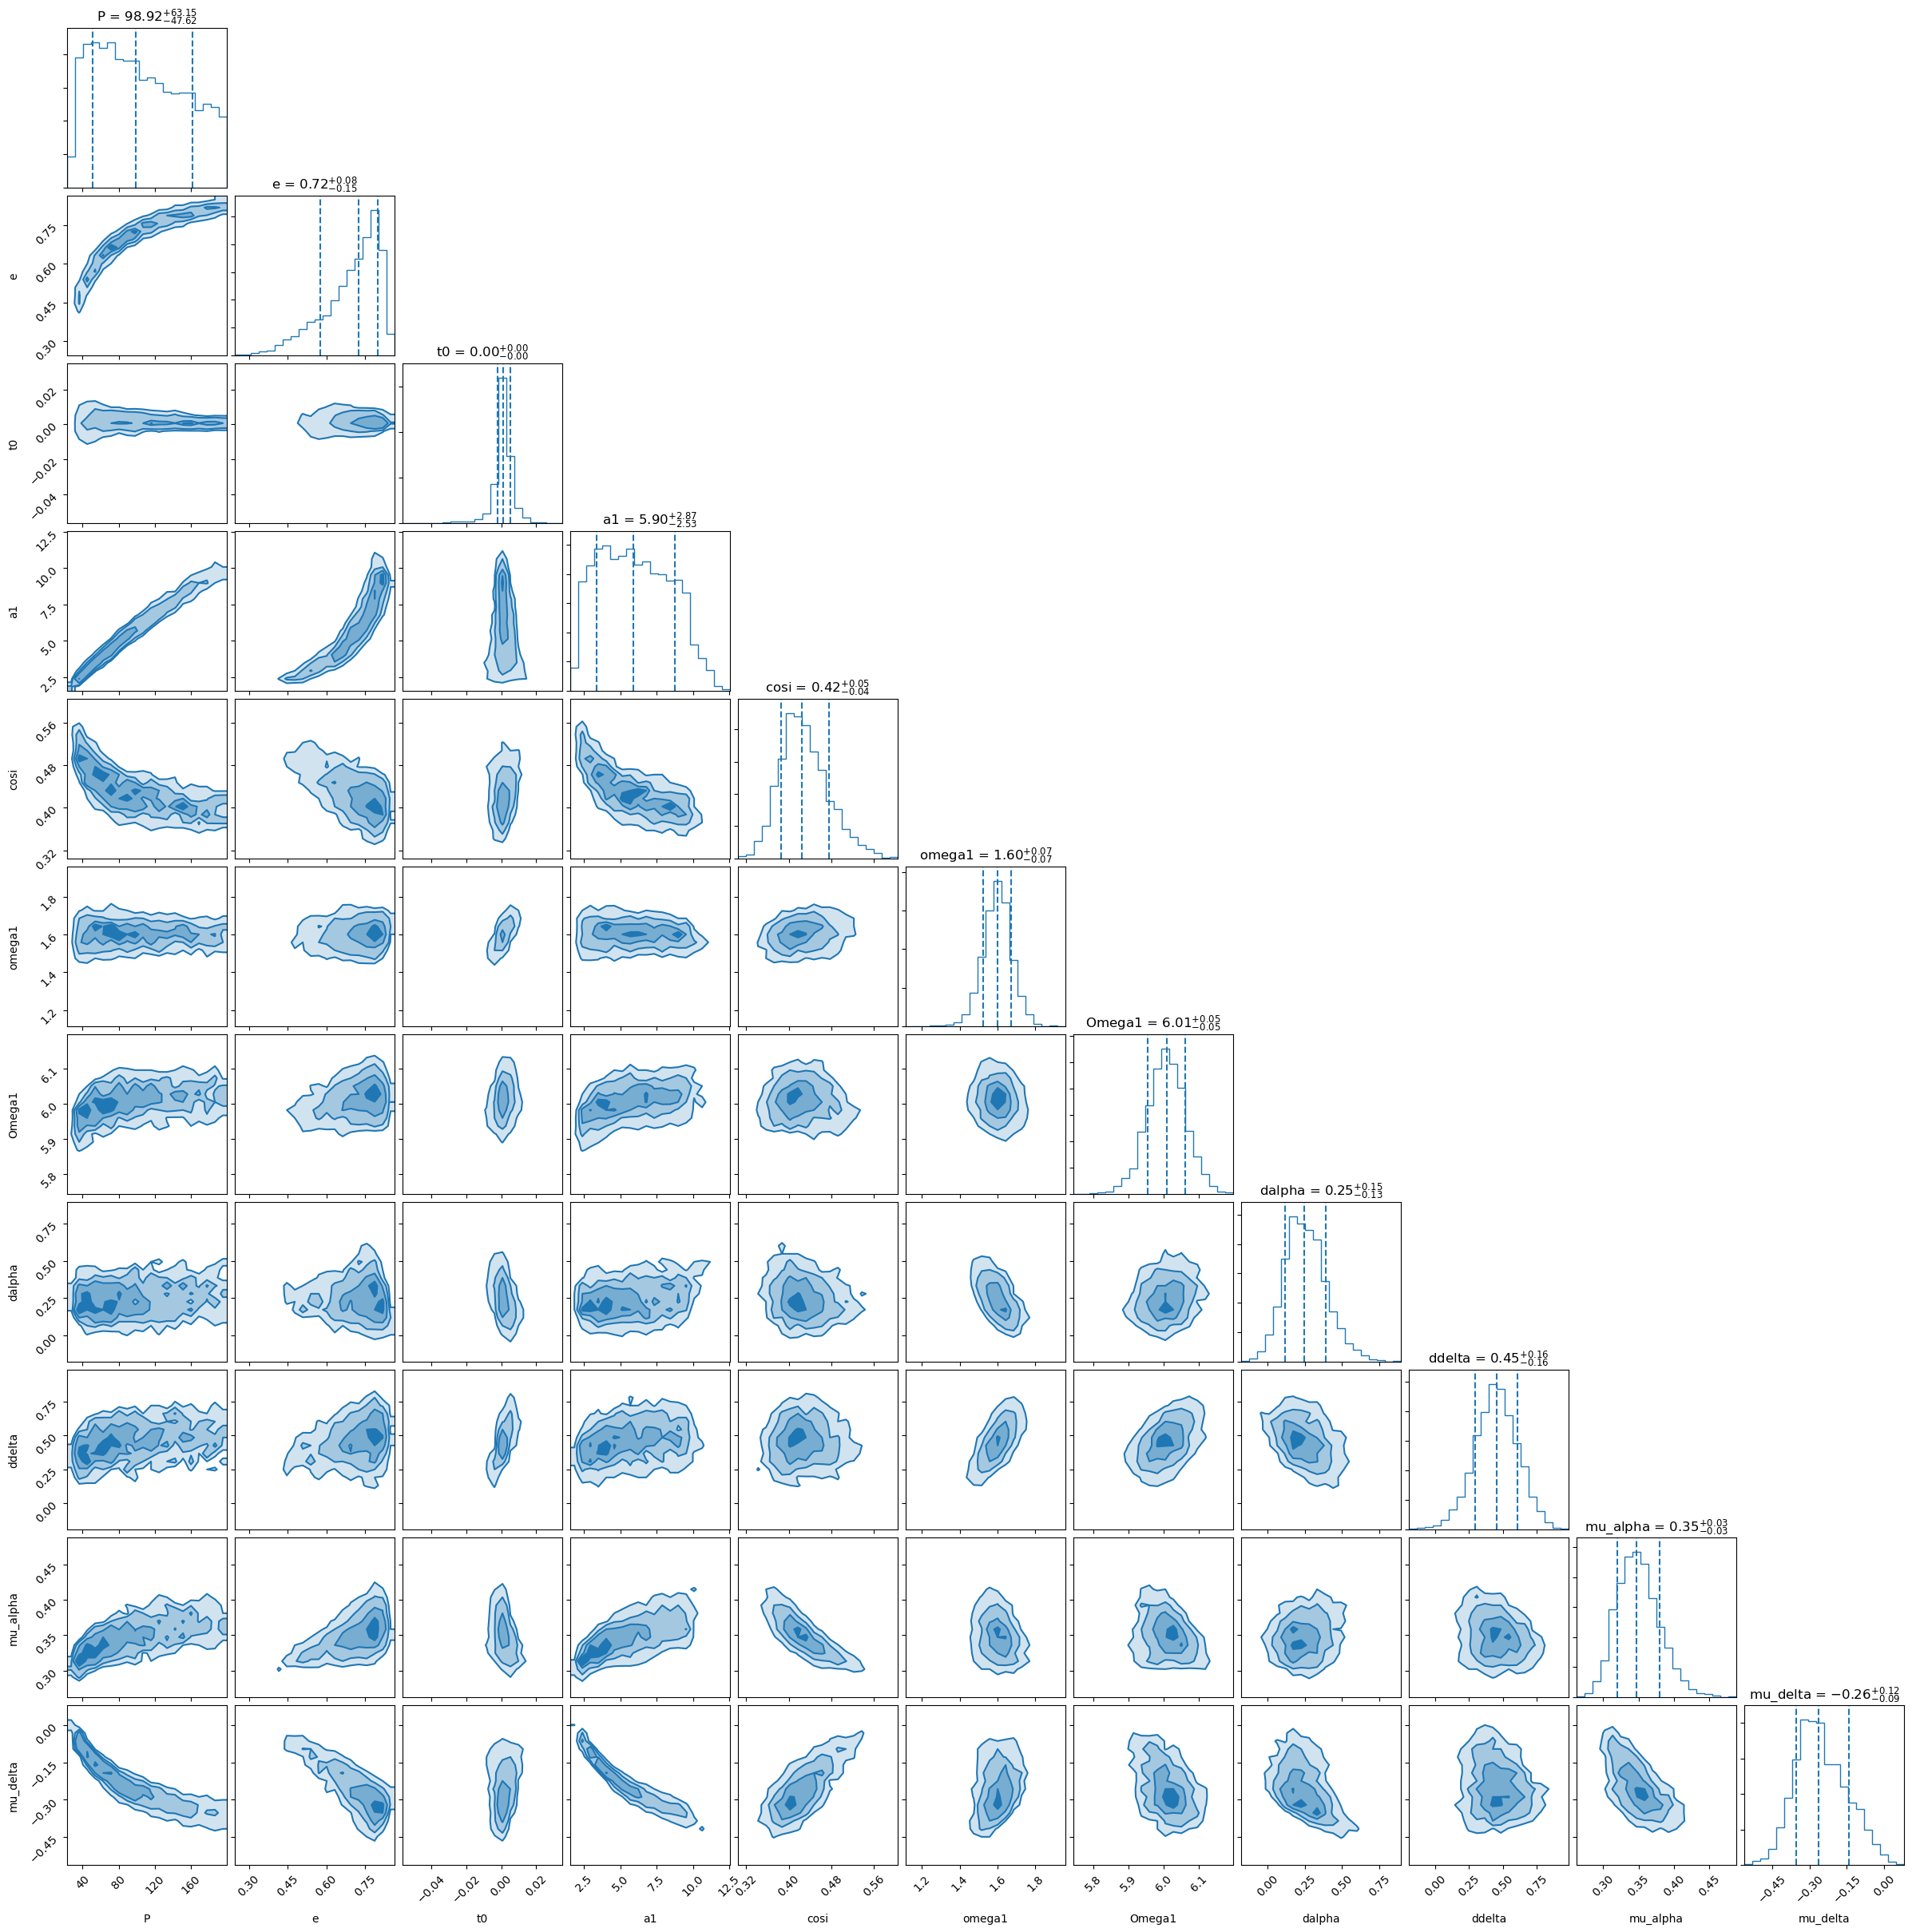

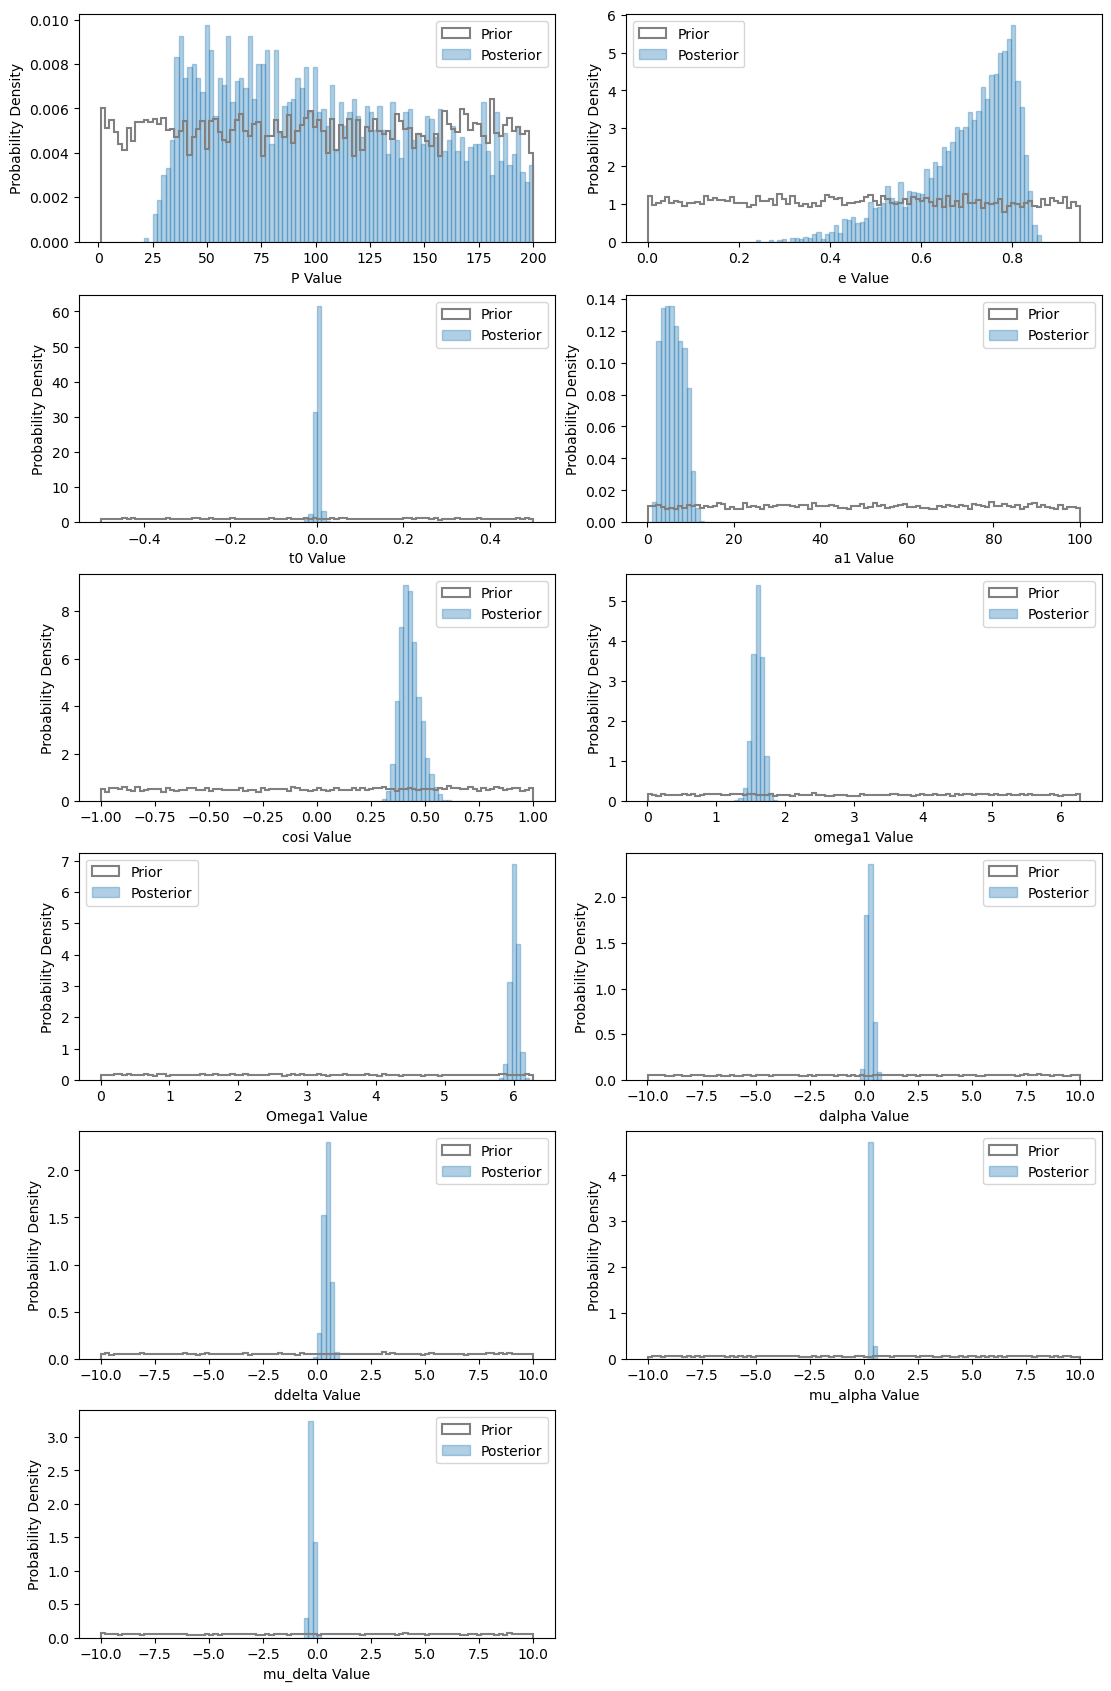

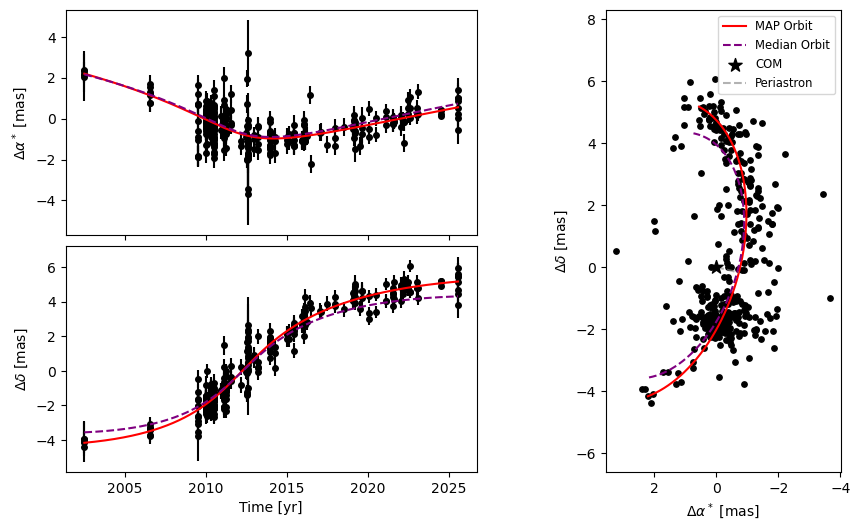

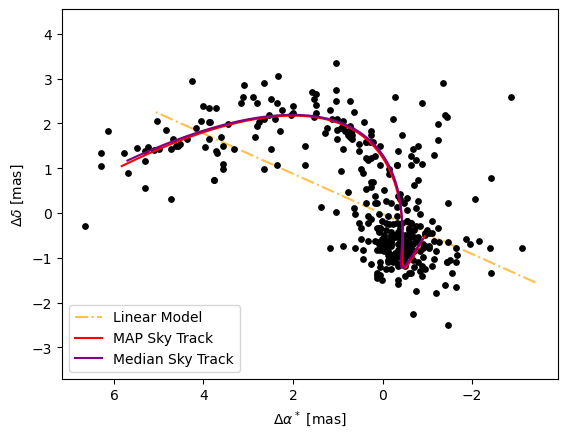

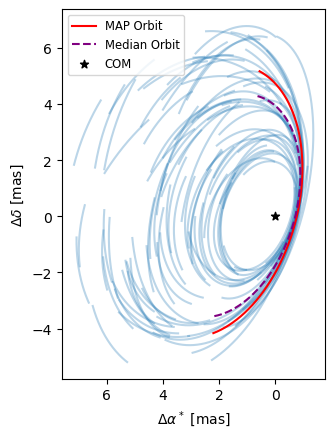

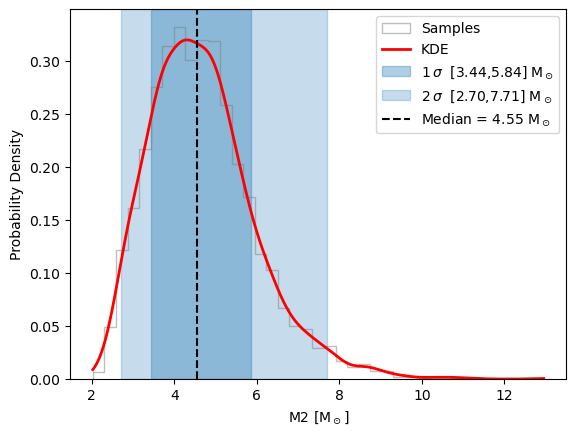

In [11]:
p.all_plots(results2,data)